In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split

df=pd.read_csv("loan_approval_dataset.csv")
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [3]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [4]:
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


## *Handling Missing values* 

In [5]:
# Handling Missing values  
# separating by categorical & numerical cols 

categorical_cols = df.select_dtypes(include = ["object"]).columns
numerical_cols = df.select_dtypes(include = ["number"]).columns

In [6]:
categorical_cols

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [7]:
numerical_cols

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')

In [8]:
categorical_cols.size + numerical_cols.size

20

In [9]:
from sklearn.impute import SimpleImputer

num_imp = SimpleImputer(strategy="mean")
df[numerical_cols] = num_imp.fit_transform(df[numerical_cols])


In [10]:
cat_imp = SimpleImputer(strategy="most_frequent")
df[categorical_cols] = cat_imp.fit_transform(df[categorical_cols])

In [11]:
df.isnull().sum()

Applicant_ID          0
Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

## *EDA*

In [12]:
# Analysizing all Categorical data

Text(0.5, 1.0, 'Is Loan approved or not ?')

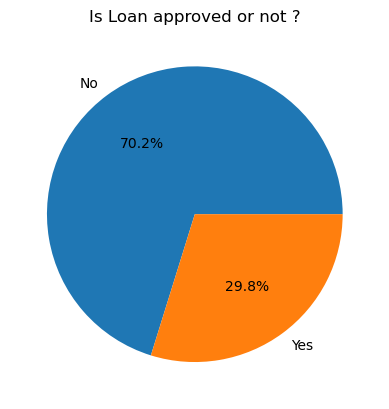

In [13]:
# Exploratory Data Analysis
# How balanced our classes are ?

classes_count = df["Loan_Approved"].value_counts()
plt.pie(classes_count, labels=["No", "Yes"], autopct = "%1.1f%%")
plt.title("Is Loan approved or not ?")

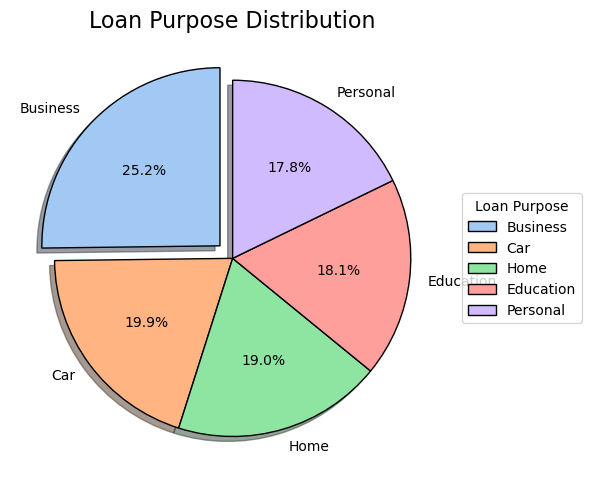

In [14]:
count = df["Loan_Purpose"].value_counts()

explode = [0.1] + [0]*(len(count)-1)
colors = sns.color_palette("pastel", len(count))

plt.figure(figsize=(6,6))
plt.pie(
    count,
    labels=count.index,
    autopct="%1.1f%%",
    explode=explode,
    colors=colors,
    startangle=90,
    shadow=True,
    wedgeprops={"edgecolor":"black", "linewidth":1}
)

plt.title("Loan Purpose Distribution", fontsize=16)
plt.legend(
    title="Loan Purpose",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()


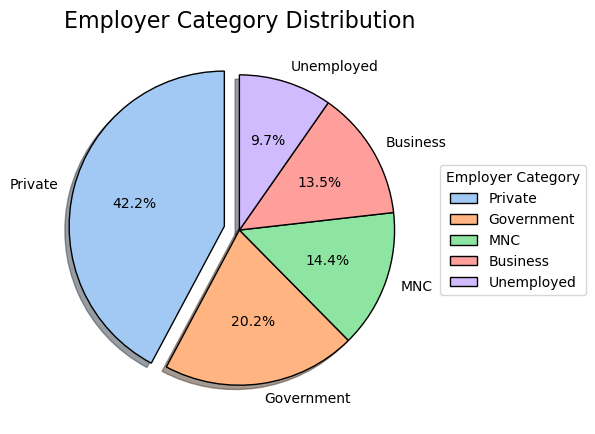

In [15]:
count = df["Employer_Category"].value_counts()

explode = [0.1] + [0]*(len(count)-1)
colors = sns.color_palette("pastel", len(count))

plt.figure(figsize=(6,6))
plt.pie(
    count,
    labels=count.index,
    autopct="%1.1f%%",
    explode=explode,
    colors=colors,
    startangle=90,
    shadow=True,
    wedgeprops={"edgecolor":"black", "linewidth":1}
)

plt.title("Employer Category Distribution", fontsize=16)
plt.legend(
    title="Employer Category",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout()

[Text(0, 0, '621'), Text(0, 0, '379')]

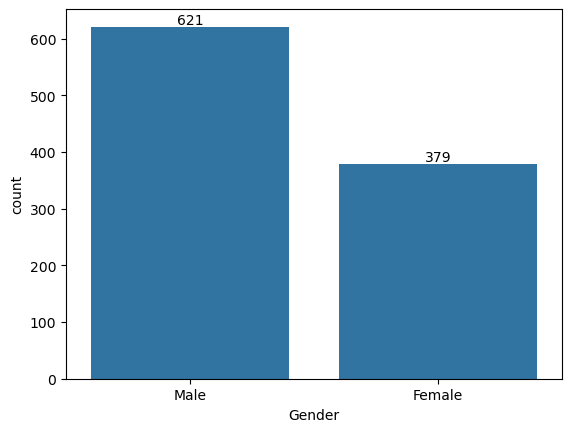

In [16]:
# Analyze categories

gender_cnt = df["Gender"].value_counts()
ax = sns.barplot(gender_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '722'), Text(0, 0, '278')]

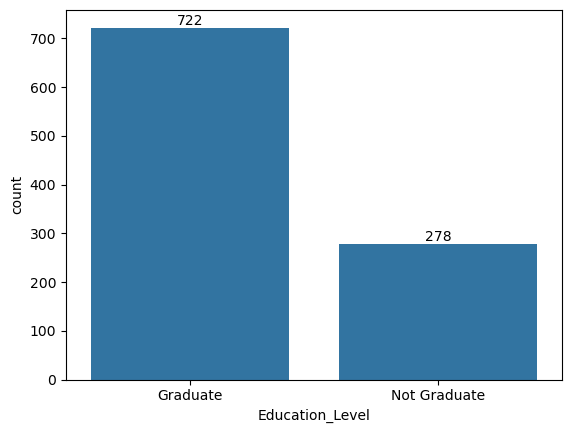

In [17]:
edu_cnt = df["Education_Level"].value_counts()
ax = sns.barplot(edu_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '515'), Text(0, 0, '213'), Text(0, 0, '182'), Text(0, 0, '90')]

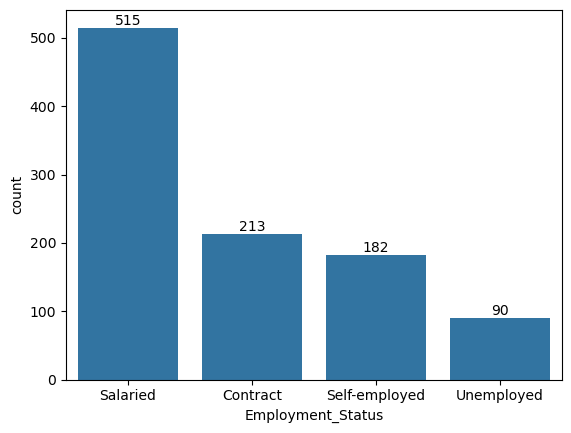

In [18]:
emp_cnt = df["Employment_Status"].value_counts()
ax = sns.barplot(emp_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '643'), Text(0, 0, '357')]

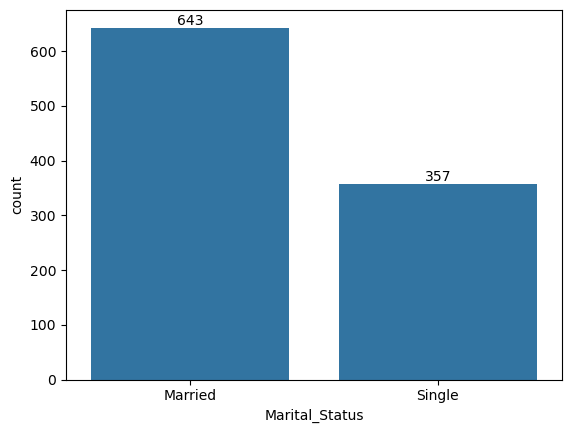

In [19]:
ms_cnt = df["Marital_Status"].value_counts()
ax = sns.barplot(ms_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '252'),
 Text(0, 0, '199'),
 Text(0, 0, '190'),
 Text(0, 0, '181'),
 Text(0, 0, '178')]

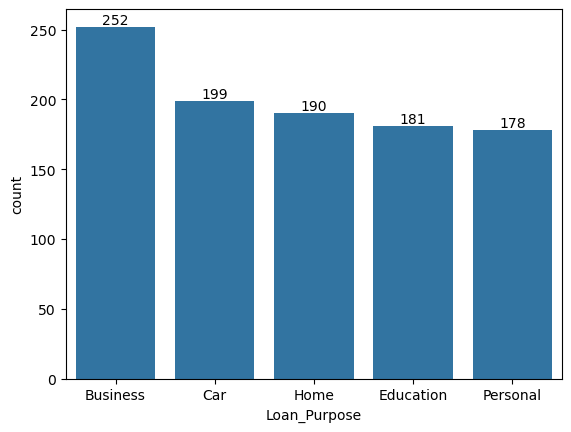

In [20]:
loan_cnt = df["Loan_Purpose"].value_counts()
ax = sns.barplot(loan_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '517'), Text(0, 0, '294'), Text(0, 0, '189')]

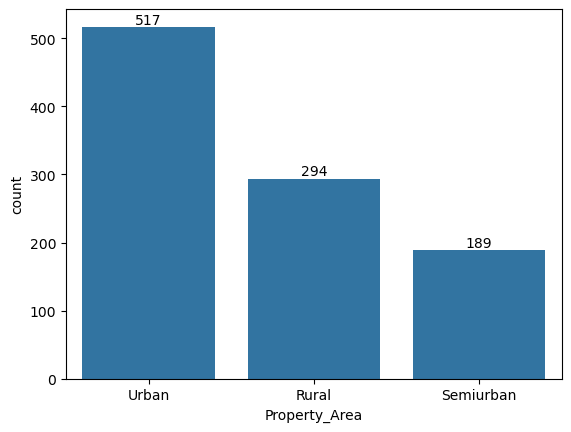

In [21]:
prop_cnt = df["Property_Area"].value_counts()
ax = sns.barplot(prop_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '422'),
 Text(0, 0, '202'),
 Text(0, 0, '144'),
 Text(0, 0, '135'),
 Text(0, 0, '97')]

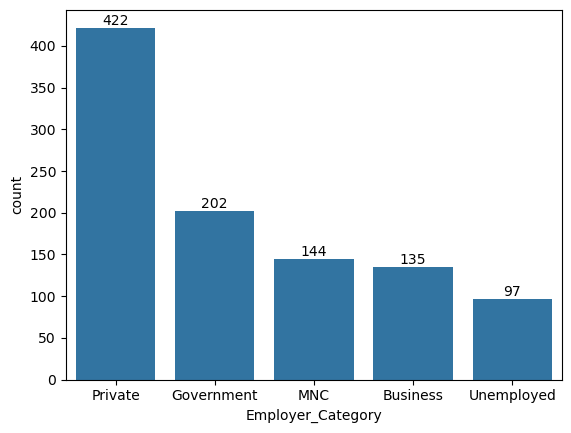

In [22]:
emp_cnt = df["Employer_Category"].value_counts()
ax = sns.barplot(emp_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '702'), Text(0, 0, '298')]

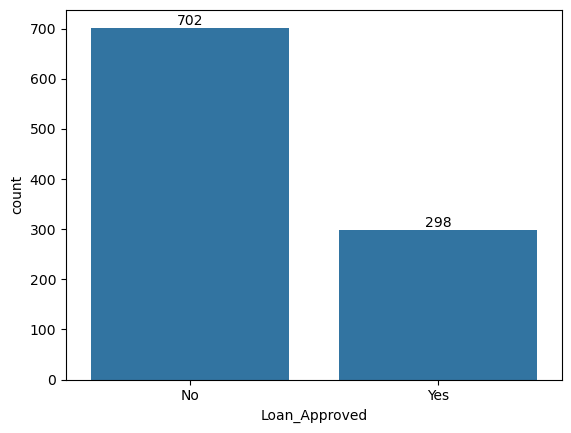

In [23]:
LA_cnt = df["Loan_Approved"].value_counts()
ax = sns.barplot(LA_cnt)
ax.bar_label(ax.containers[0])

<Axes: xlabel='Applicant_Income', ylabel='Count'>

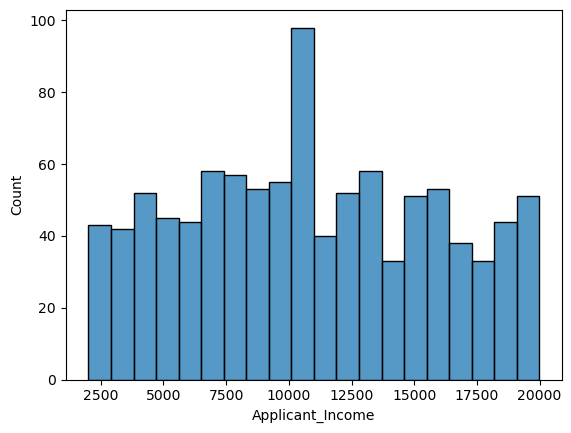

In [24]:
## Analyszing income
sns.histplot(
    data = df,
    x = "Applicant_Income",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

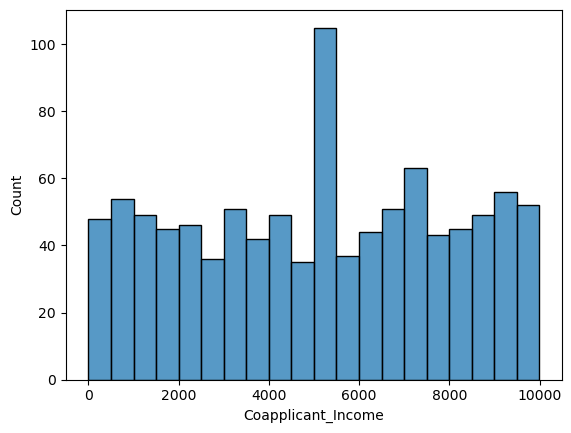

In [25]:
sns.histplot(
    data = df,
    x = "Coapplicant_Income",
    bins=20
)

- *Applicant_Income have a maximum range between 10000 to 12000 while Coapplicant_income is between 4000 to 6000. and both follows a similar pattern*

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

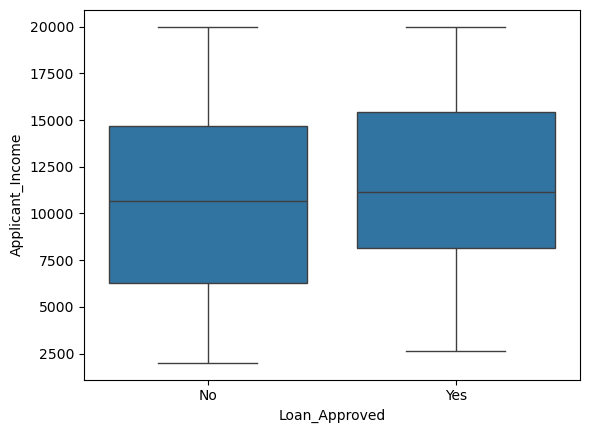

In [26]:
# Outliers - box plots

sns.boxplot(
    data=df,
    x="Loan_Approved",
    y="Applicant_Income"
)


- *No such Outliers found in approved as well as not approved category*
- one more thing to analyse - Income might be one of the factor for approvement of Loan as we can see rejected ones has slightly less Income compared to Approved ones.

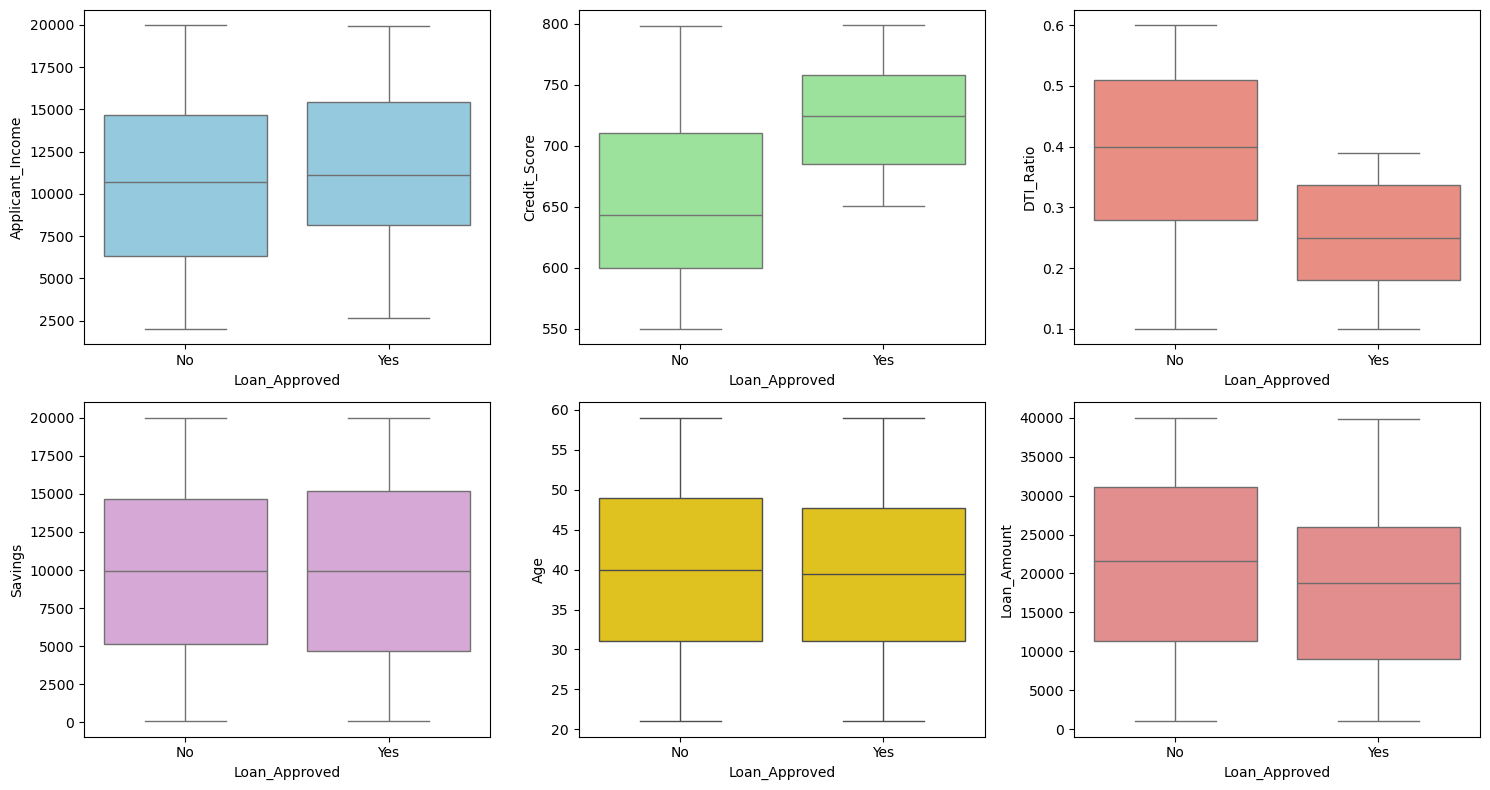

In [27]:
# Analyzing multiple box-plot for outliers

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.boxplot(ax=axes[0,0], data=df, x="Loan_Approved", y="Applicant_Income", color="skyblue")
sns.boxplot(ax=axes[0,1], data=df, x="Loan_Approved", y="Credit_Score", color="lightgreen")
sns.boxplot(ax=axes[0,2], data=df, x="Loan_Approved", y="DTI_Ratio", color="salmon")

sns.boxplot(ax=axes[1,0], data=df, x="Loan_Approved", y="Savings", color="plum")
sns.boxplot(ax=axes[1,1], data=df, x="Loan_Approved", y="Age", color="gold")
sns.boxplot(ax=axes[1,2], data=df, x="Loan_Approved", y="Loan_Amount", color="lightcoral")

plt.tight_layout()

### *As such no Outliers found but we have more things to look after -*
- *Credit Score:* Applicants whose loans were approved ("Yes") generally have higher credit scores than those whose loans were rejected ("No"), indicating that credit score is an important factor in loan approval.
 - *DTI Ratio (Debt-to-Income Ratio):* Approved applicants tend to have a lower DTI ratio, while rejected applicants have a higher DTI ratio. This suggests that borrowers with lower debt relative to their income are more likely to receive loan approval.
- *Income, Savings, Age, and Loan Amount:* The distributions of Applicant Income, Savings, Age, and Loan Amount are quite similar for both approved and rejected applicants, showing no significant difference or noticeable outliers. These features alone may have less influence on loan approval compared to Credit Score and DTI Ratio.

<Axes: xlabel='Credit_Score', ylabel='Count'>

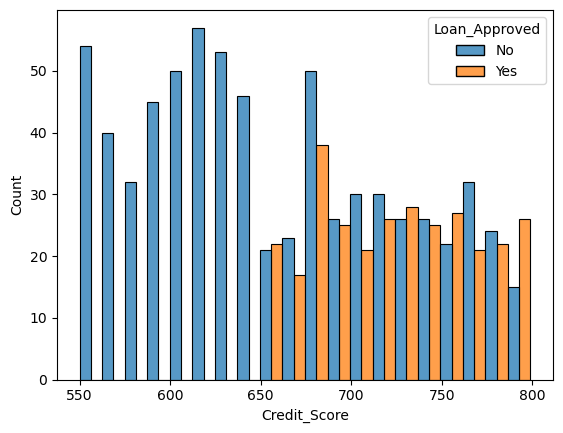

In [28]:
# Since Credit score is an important aspect of Loan Approved 

sns.histplot(
    data=df,
    x="Credit_Score",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

- *Credit Score is a strong predictor of loan approval* — applicants with higher credit scores (around 680–790) are much more likely to have their loans approved, while lower credit scores (550–650) are predominantly associated with loan rejection.

<Axes: xlabel='Applicant_Income', ylabel='Count'>

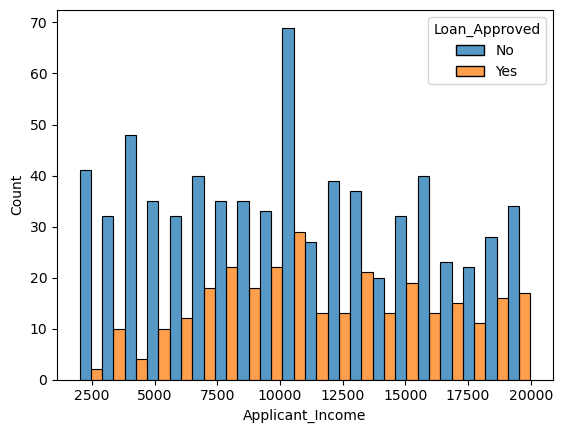

In [29]:
# Annual Income also plays  an important aspect of Loan Approved 

sns.histplot(
    data=df,
    x="Applicant_Income",
    hue="Loan_Approved",
    bins=20,
    multiple="dodge"
)

- *Applicant Income* alone is not a strong predictor of loan approval, as approved and rejected applications are distributed across almost all income levels, indicating that income is considered alongside other factors (such as credit score) rather than independently.

In [30]:
# Remove unnecessary dat - Applicant Id"
df = df.drop("Applicant_ID", axis=1)

In [31]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [32]:
df.columns

Index(['Applicant_Income', 'Coapplicant_Income', 'Employment_Status', 'Age',
       'Marital_Status', 'Dependents', 'Credit_Score', 'Existing_Loans',
       'DTI_Ratio', 'Savings', 'Collateral_Value', 'Loan_Amount', 'Loan_Term',
       'Loan_Purpose', 'Property_Area', 'Education_Level', 'Gender',
       'Employer_Category', 'Loan_Approved'],
      dtype='object')

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

## *Feature Encoding*

In [34]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Label Encoding on edu-lvl & loan-approved as 0 or 1:
le = LabelEncoder()
df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])
df.head()


,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [35]:
cols=["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown= "ignore")
encoded = ohe.fit_transform(df[cols])
encoded_df = pd.DataFrame(encoded, columns= ohe.get_feature_names_out(cols), index=df.index)

In [36]:
encoded_df.head()

,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Marital_Status_Single,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [37]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,1,Female,Private,0
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,0,Male,Private,0
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,0,Female,Government,1
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,0,Female,Government,0
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,0,Male,Private,1


In [38]:
#cancat Encoded_df cols  into orginal dataset and removing original ones as we got encoded columns 
df=pd.concat([df.drop(columns = cols), encoded_df], axis = 1)
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [39]:
df.describe()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,...,0.181000,0.190000,0.178000,0.189000,0.517000,0.621000,0.202000,0.144000,0.422000,0.097000
std,4933.339492,2868.563488,10.857445,1.077058,69.537662,1.370603,0.140683,5712.189236,13982.086562,11212.555805,...,0.385211,0.392497,0.382704,0.391705,0.499961,0.485381,0.401693,0.351265,0.494126,0.296106
min,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6857.000000,2701.250000,31.000000,1.000000,618.000000,1.000000,0.230000,4964.000000,13166.000000,10478.250000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,10852.571579,5082.455789,39.971579,1.237368,676.033684,2.000000,0.347263,9940.452632,24802.792632,20522.825263,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,14973.250000,7452.750000,49.000000,2.000000,735.000000,3.000000,0.470000,14784.750000,36396.000000,29683.250000,...,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

## *Corelation Heatmap*

In [41]:
num_cols = df.select_dtypes(include="number")
corr_matrix = num_cols.corr()

In [42]:
corr_matrix #Relation between numerical variables

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
Applicant_Income,1.000000,0.007545,-0.023988,-0.026658,-0.009818,-0.010457,-0.009107,-0.028358,0.018789,-0.024143,...,0.032794,0.074209,-0.031234,0.004845,-0.036260,-0.020871,-0.025011,0.102589,-0.044639,-0.011995
Coapplicant_Income,0.007545,1.000000,0.014306,-0.026733,0.058423,0.012418,0.058078,-0.015047,0.009457,0.001596,...,0.028000,0.016022,0.059549,-0.010058,0.030045,-0.010148,-0.001146,0.037640,0.004312,-0.047929
Age,-0.023988,0.014306,1.000000,-0.018767,-0.004212,0.023330,0.007903,-0.000986,0.037382,0.013502,...,-0.006283,0.029865,0.037293,0.003100,-0.025661,0.048402,-0.066041,0.021232,-0.012960,0.072462
Dependents,-0.026658,-0.026733,-0.018767,1.000000,-0.007687,-0.026338,0.011498,-0.004981,0.023004,-0.017409,...,-0.044642,0.027343,-0.005785,-0.032278,0.024082,0.013706,-0.009250,-0.018757,0.030197,-0.054147
Credit_Score,-0.009818,0.058423,-0.004212,-0.007687,1.000000,-0.007130,0.002338,-0.065353,0.007865,0.001002,...,0.026013,-0.008658,0.015324,-0.006946,0.004445,-0.039739,-0.007076,0.066736,-0.000049,-0.046087
Existing_Loans,-0.010457,0.012418,0.023330,-0.026338,-0.007130,1.000000,0.047008,0.034435,-0.049916,-0.021035,...,-0.010035,0.001777,0.023212,-0.053971,0.035629,-0.038762,-0.009642,0.030520,-0.019306,0.045391
DTI_Ratio,-0.009107,0.058078,0.007903,0.011498,0.002338,0.047008,1.000000,0.004663,-0.009622,0.075784,...,0.040432,-0.014125,-0.036648,0.044898,-0.006156,0.009624,-0.007214,0.002090,-0.003506,0.026018
Savings,-0.028358,-0.015047,-0.000986,-0.004981,-0.065353,0.034435,0.004663,1.000000,0.015481,-0.012208,...,0.032558,-0.012217,-0.028948,0.005438,0.016833,-0.006667,-0.011683,0.004381,-0.030208,0.027178
Collateral_Value,0.018789,0.009457,0.037382,0.023004,0.007865,-0.049916,-0.009622,0.015481,1.000000,0.002660,...,0.040406,-0.050975,-0.007120,0.020061,0.007975,0.000897,0.035760,-0.013464,-0.014480,-0.009655
Loan_Amount,-0.024143,0.001596,0.013502,-0.017409,0.001002,-0.021035,0.075784,-0.012208,0.002660,1.000000,...,-0.006119,-0.000930,0.032498,0.040206,-0.050076,0.103456,0.013108,-0.025975,0.013923,-0.026566


Text(0.5, 1.0, 'Correlation Matrix')

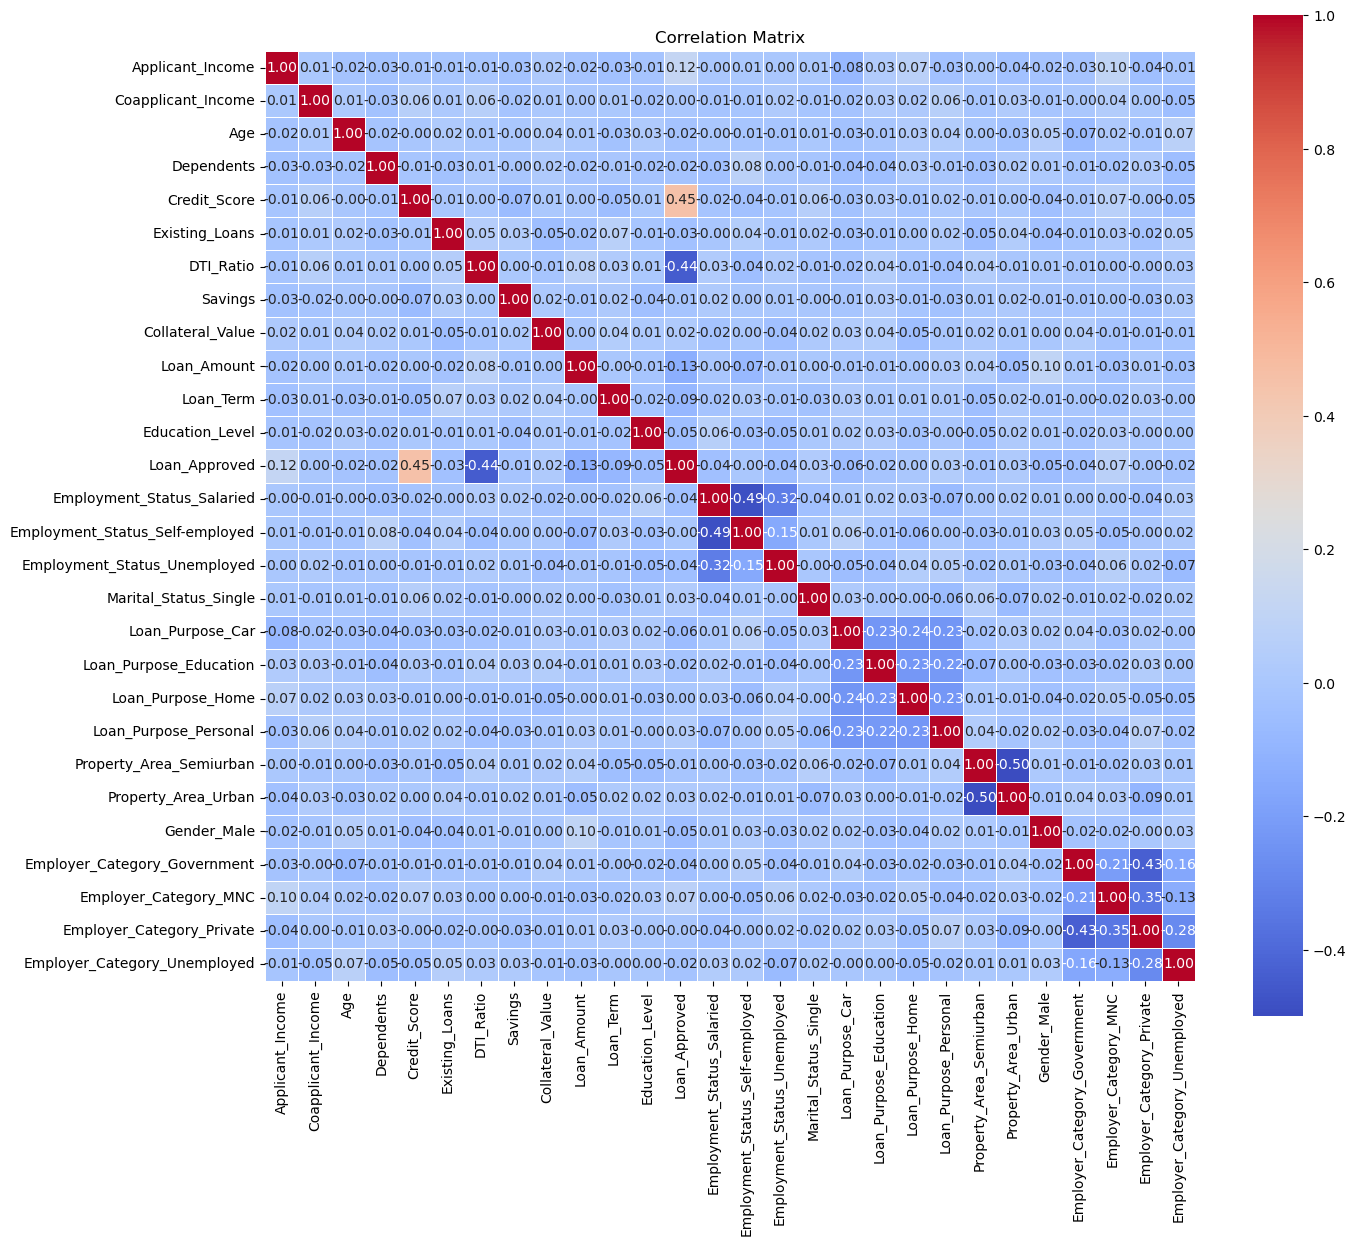

In [43]:
plt.figure(figsize=(15, 13))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Matrix")

## *MACHINE LEARNING MODEL TRAINING*

### *Train-Test-Split & Feature Scaling*

In [44]:
# Train Test Split

X = df.drop("Loan_Approved", axis =1)
y = df["Loan_Approved"]

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

In [46]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## *Train & Evaluate Models*

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# Logistic Regression
log_model =  LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

# Evaluation
print("----Logistic Regression Model---------")
print("Precision score", precision_score(y_test, y_pred))
print("Recall score", recall_score(y_test, y_pred))
print("f1 score", f1_score(y_test, y_pred))
print("Accuracy score", accuracy_score(y_test, y_pred))
print("Confusion matrix", confusion_matrix(y_test, y_pred))

----Logistic Regression Model---------
Precision score 0.7833333333333333
Recall score 0.7704918032786885
f1 score 0.7768595041322314
Accuracy score 0.865
Confusion matrix [[126  13]
 [ 14  47]]


 - We will Consider Precision and then Recall as our problem Statement is -
 -  Good customers sometimes get rejected ( We need Recall score ) = 77 %
 -  for High-risk customers sometimes get approved ( Precision is required ) - 78 %

In [48]:
# kNN Classifier 

from sklearn.neighbors import KNeighborsClassifier

knn_model =  KNeighborsClassifier(n_neighbors=13)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

# Evaluation
print("----kNN Model---------")
print("Precision score", precision_score(y_test, y_pred))
print("Recall score", recall_score(y_test, y_pred))
print("f1 score", f1_score(y_test, y_pred))
print("Accuracy score", accuracy_score(y_test, y_pred))
print("Confusion matrix", confusion_matrix(y_test, y_pred))

----kNN Model---------
Precision score 0.7317073170731707
Recall score 0.4918032786885246
f1 score 0.5882352941176471
Accuracy score 0.79
Confusion matrix [[128  11]
 [ 31  30]]


- Since the dataset has more features -  kNN isnt the accurate model to evaluate we can see Recall -> 49%, even if we Change n_neighbors it still wont perform well

In [49]:
# Naive Bayes Classifier 

from sklearn.naive_bayes import GaussianNB

gnb_model =  GaussianNB()
gnb_model.fit(X_train_scaled, y_train)

y_pred = gnb_model.predict(X_test_scaled)

# Evaluation
print("---- Naive BayesModel---------")
print("Precision score", precision_score(y_test, y_pred))
print("Recall score", recall_score(y_test, y_pred))
print("f1 score", f1_score(y_test, y_pred))
print("Accuracy score", accuracy_score(y_test, y_pred))
print("Confusion matrix", confusion_matrix(y_test, y_pred))

---- Naive BayesModel---------
Precision score 0.8035714285714286
Recall score 0.7377049180327869
f1 score 0.7692307692307693
Accuracy score 0.865
Confusion matrix [[128  11]
 [ 16  45]]


- *Naive Bayes has better precision than Logistic regression* as the problem statement- ("High-risk customers sometimes get approved") is on priority which is 80% and Recal Score is slightly lower but its considerable as we need Precision on priority

## *Best Model on the basis of precision => Naive Bayes*

In [50]:
# Feature Engineering -- To improve model

# Adding & Transform Features
## looking after headtmap DTI and Credit Score Created a major impact so added Squared Feature to enchance performance

df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2


X = df.drop(columns=["Loan_Approved", "Credit_Score", "DTI_Ratio"])
y = df["Loan_Approved"]

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# For datafram results
results = []

# Logistic Regression
log_model =  LogisticRegression()
log_model.fit(X_train_scaled, y_train)

y_pred = log_model.predict(X_test_scaled)

# Evaluation
results.append({
    "Model": "Logistic Regression",
    "Accuracy": round(accuracy_score(y_test, y_pred), 4),
    "Precision": round(precision_score(y_test, y_pred), 4),
    "Recall": round(recall_score(y_test, y_pred), 4),
    "F1 Score": round(f1_score(y_test, y_pred), 4)
})

# kNN Classifier 
knn_model =  KNeighborsClassifier(n_neighbors=13)
knn_model.fit(X_train_scaled, y_train)

y_pred = knn_model.predict(X_test_scaled)

# Evaluation
results.append({
    "Model": "KNN",
    "Accuracy": round(accuracy_score(y_test, y_pred), 4),
    "Precision": round(precision_score(y_test, y_pred), 4),
    "Recall": round(recall_score(y_test, y_pred), 4),
    "F1 Score": round(f1_score(y_test, y_pred), 4)
})

# Naive Bayes Classifier 
gnb_model =  GaussianNB()
gnb_model.fit(X_train_scaled, y_train)

y_pred = gnb_model.predict(X_test_scaled)

# Evaluation
results.append({
    "Model": "Gaussian Naive Bayes",
    "Accuracy": round(accuracy_score(y_test, y_pred), 4),
    "Precision": round(precision_score(y_test, y_pred), 4),
    "Recall": round(recall_score(y_test, y_pred), 4),
    "F1 Score": round(f1_score(y_test, y_pred), 4)
})

# Final Results DataFrame
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.875,0.7903,0.8033,0.7967
1,KNN,0.785,0.7368,0.4590,0.5657
2,Gaussian Naive Bayes,0.865,0.7833,0.7705,0.7769


In [51]:
# After Feature Engineering there is slighter better Difference in logistic Regression. 
# Although if we look into balance of Precision and Recall would go for => Logistic Regression
# if precision is the priority than Naive Bayes is better..
# We have more model which can perform better as we were evaluating only between logistic, Knn, Naive bayes